# 多房室 HH 网络的 DBNN-GIF 约化

本实验使用 4 个兴奋性和 3 个抑制性 HH 上游细胞驱动一个多房室 HH 输出细胞，并训练 DBNN-GIF 替代该输出细胞。

In [1]:
import json
from pathlib import Path
import sys
import time

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'braincell').is_dir() and (candidate / 'examples').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the BrainCell repository root.')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import braincell
from braincell import mech
from braincell.filter import AllRegion, at
from braincell.reduction.dbnn import DBNN, DBNNReduction, DBNNTrainer
from braincell.reduction.dbnn.dataset import rasterize_events
from braincell.reduction.dbnn.layout import build_channel_layout
from braincell.reduction.dbnn.stimulus import SparseEvents, StimulusPlan

In [2]:
DT = 1.0 * u.ms
DURATION_MS = 100.0
N_TRACES = 1000
N_EXCITATORY = 4
N_INHIBITORY = 3
INPUT_NAMES = tuple(f'exc_{index}' for index in range(N_EXCITATORY)) + tuple(
    f'inh_{index}' for index in range(N_INHIBITORY)
)
INPUT_WEIGHTS_US = np.asarray((0.005,) * N_EXCITATORY + (0.001,) * N_INHIBITORY, dtype=np.float32)
INPUT_LOCATIONS = (
    at('dend_a', 0.20),
    at('dend_a', 0.55),
    at('dend_b', 0.25),
    at('dend_b', 0.65),
    at('soma', 0.50),
    at('dend_a', 0.82),
    at('dend_b', 0.82),
)
OUTPUT_DIR = REPO_ROOT / 'artifacts' / 'reduction' / 'DBNN_test2_network'
TIME_LIMIT_SECONDS = 9.0 * 60.0

## 上游细胞与多房室输出细胞

每个上游 population 有 1000 个独立 HH 细胞。每条轨迹的两脉冲电流钳具有独立的首脉冲延迟、脉冲间隔和幅度。输出细胞具有胞体、基底树突和顶树突，共 10 个计算体积。

In [3]:
def paint_hh(cell: braincell.Cell) -> None:
    cell.paint(
        AllRegion(),
        mech.CableProperty(
            resting_potential=-65.0 * u.mV,
            membrane_capacitance=1.0 * u.uF / u.cm**2,
            axial_resistivity=100.0 * u.ohm * u.cm,
        ),
        mech.Ion('SodiumFixed', E=50.0 * u.mV),
        mech.Ion('PotassiumFixed', E=-77.0 * u.mV),
        mech.Channel('IL', name='leak', g_max=0.3 * u.mS / u.cm**2, E=-54.3 * u.mV),
        mech.Channel('Na_HH1952', name='na', g_max=120.0 * u.mS / u.cm**2),
        mech.Channel('K_HH1952', name='k', g_max=36.0 * u.mS / u.cm**2),
    )


def build_source_cell(pop_size, name: str, source_index: int) -> braincell.Cell:
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type='soma'
    )
    cell = braincell.Cell(
        braincell.Morphology.from_root(soma, name='soma'),
        cv_policy=braincell.CVPerBranch(),
        pop_size=pop_size,
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        name=name,
    )
    paint_hh(cell)
    random = brainstate.random.RandomState(20260909 + source_index)
    first_pulse_ms = np.asarray(random.uniform(3.0, 20.0, size=(pop_size[0],)), dtype=np.float32)
    pulse_gap_ms = np.asarray(random.uniform(25.0, 60.0, size=(pop_size[0],)), dtype=np.float32)
    pulse_amplitudes_na = np.asarray(random.uniform(0.8, 1.2, size=(pop_size[0], 2)), dtype=np.float32)
    durations_ms = np.stack((np.ones(pop_size[0]), pulse_gap_ms, np.ones(pop_size[0])), axis=-1)
    amplitudes_na = np.stack(
        (pulse_amplitudes_na[:, 0], np.zeros(pop_size[0]), pulse_amplitudes_na[:, 1]), axis=-1
    )
    cell.place(
        at('soma', 0.5),
        mech.CurrentClamp(
            delay=first_pulse_ms * u.ms,
            durations=durations_ms * u.ms,
            amplitudes=amplitudes_na * u.nA,
        ),
    )
    return cell


def build_output_morphology() -> braincell.Morphology:
    soma = braincell.Branch.from_lengths(
        lengths=[20.0] * u.um, radii=[10.0, 10.0] * u.um, type='soma'
    )
    dend_a = braincell.Branch.from_lengths(
        lengths=[160.0] * u.um, radii=[2.0, 1.0] * u.um, type='basal_dendrite'
    )
    dend_b = braincell.Branch.from_lengths(
        lengths=[220.0] * u.um, radii=[2.5, 0.8] * u.um, type='apical_dendrite'
    )
    morphology = braincell.Morphology.from_root(soma, name='soma')
    morphology.soma.dend_a = dend_a
    morphology.soma.dend_b = dend_b
    return morphology


def build_output_cell(pop_size, name: str, *, record_soma_voltage: bool):
    cell = braincell.Cell(
        build_output_morphology(),
        cv_policy=braincell.CVPerBranchList((1, 4, 5)),
        pop_size=pop_size,
        V_init=-65.0 * u.mV,
        V_th=0.0 * u.mV,
        name=name,
    )
    paint_hh(cell)
    specs = tuple(
        mech.Synapse('ExpSyn', name=input_name, tau=2.0 * u.ms, e=0.0 * u.mV)
        if channel < N_EXCITATORY
        else mech.Synapse('Exp2Syn', name=input_name, tau1=0.5 * u.ms, tau2=6.0 * u.ms, e=-80.0 * u.mV)
        for channel, input_name in enumerate(INPUT_NAMES)
    )
    for location, spec in zip(INPUT_LOCATIONS, specs):
        cell.place(location, spec)
    if record_soma_voltage:
        cell.soma.record('voltage', braincell.observe.state('v'))
    return cell, specs


def require_time_budget(start_time: float) -> None:
    if time.monotonic() - start_time > TIME_LIMIT_SECONDS:
        raise TimeoutError('DBNN_test2_network exceeded its nine-minute internal runtime budget.')

## 生成网络教师数据

上游 HH 细胞的实时 spike 端口逐一连接到 output 的命名突触。训练输入从教师网络实际产生的 spike 事件中提取。

In [4]:
def build_teacher_network():
    network = braincell.Network('hh_microcircuit_teacher')
    output_cell, _ = build_output_cell((N_TRACES,), 'output_teacher', record_soma_voltage=True)
    output_population = network.add_population('output', output_cell)
    positions = np.arange(N_TRACES, dtype=np.int64)
    for channel, input_name in enumerate(INPUT_NAMES):
        source_cell = build_source_cell((N_TRACES,), input_name, channel)
        source_population = network.add_population(input_name, source_cell)
        network.connect(
            f'{input_name}_to_output',
            source=source_population.event_outputs['spike'][positions],
            synapse=output_population.synapses[input_name][positions],
            weight=INPUT_WEIGHTS_US[channel] * u.uS,
        )
    return network


start_time = time.monotonic()
teacher_network = build_teacher_network()
teacher_result = teacher_network.run(dt=DT, duration=DURATION_MS * u.ms)
time_ms = np.asarray(teacher_result.time.to_decimal(u.ms), dtype=np.float32)
voltage_mv = np.asarray(
    teacher_result.samples['output']['voltage'].values.to_decimal(u.mV), dtype=np.float32
).T
event_trace_ids = []
event_channel_ids = []
event_times_ms = []
for channel, input_name in enumerate(INPUT_NAMES):
    spikes = teacher_result.events[input_name]['spike']
    event_trace_ids.append(np.asarray(spikes.source_id, dtype=np.int64))
    event_channel_ids.append(np.full(len(spikes.source_id), channel, dtype=np.int64))
    event_times_ms.append(np.asarray(spikes.time.to_decimal(u.ms), dtype=np.float32))
plan = StimulusPlan(
    layout_fingerprint='pending',
    n_traces=N_TRACES,
    events=SparseEvents(
        trace_id=np.concatenate(event_trace_ids),
        channel_id=np.concatenate(event_channel_ids),
        time_ms=np.concatenate(event_times_ms),
    ),
    channel_weights=np.ones((N_TRACES, len(INPUT_NAMES)), dtype=np.float32),
    duration_ms=DURATION_MS,
    seeds=tuple(range(1000, 1000 + N_TRACES)),
    protocol_labels=('clamped_hh_microcircuit',) * N_TRACES,
    split='all',
)
template, specs = build_output_cell((1,), 'output_template', record_soma_voltage=False)
layout = build_channel_layout(
    template,
    specs,
    reference_weights_us=tuple(float(weight) for weight in INPUT_WEIGHTS_US),
    training_ranges=((0.0, 1.0),) * len(INPUT_NAMES),
)
plan = StimulusPlan(
    layout_fingerprint=layout.fingerprint,
    n_traces=plan.n_traces,
    events=plan.events,
    channel_weights=plan.channel_weights,
    duration_ms=plan.duration_ms,
    seeds=plan.seeds,
    protocol_labels=plan.protocol_labels,
    split=plan.split,
)
inputs = rasterize_events(plan, dt_ms=float(DT.to_decimal(u.ms)), input_alignment='interval-start')[:, :, :-1]
if voltage_mv.shape != (N_TRACES, inputs.shape[-1]):
    raise RuntimeError(f'Teacher voltage shape {voltage_mv.shape} does not match inputs {inputs.shape}.')
spike_times_ms = tuple(time_ms[1:][(row[1:] >= 0.0) & (row[:-1] < 0.0)] for row in voltage_mv)
data = {'inputs': inputs, 'targets': voltage_mv, 'spike_times_ms': spike_times_ms}
train_data = {key: value[:800] if hasattr(value, 'shape') else value[:800] for key, value in data.items()}
validation_data = {key: value[800:900] if hasattr(value, 'shape') else value[800:900] for key, value in data.items()}
test_data = {key: value[900:] if hasattr(value, 'shape') else value[900:] for key, value in data.items()}
{
    'populations': len(teacher_network.populations),
    'connections': len(teacher_network.connections),
    'source_spikes': int(sum(len(teacher_result.events[name]['spike'].time) for name in INPUT_NAMES)),
    'output_spikes': int(sum(len(times) for times in spike_times_ms)),
    'input_shape': inputs.shape,
}

{'populations': 8,
 'connections': 7,
 'source_spikes': 14000,
 'output_spikes': 1473,
 'input_shape': (1000, 7, 100)}

## 训练 DBNN-GIF

电压拟合仅使用阈下和远离 spike 的样本；GIF 校准使用验证集 spike 时间。

In [5]:
model = DBNN(layout, mode='f', dt=DT)
model.source_fingerprint = 'dbnn-test2-hh-microcircuit-v1'
model.input_alignment = 'interval-start'
params = model.get_params()
params['bias'] = np.asarray(np.mean(train_data['targets'][:, 0]), dtype=np.float32)
model.set_params(params)
trainer = DBNNTrainer(
    model,
    learning_rate=0.01,
    lr_step_size=200,
    lr_gamma=0.5,
    loss='masked_mse',
    seed=42,
    initialization_options={'maxiter': 8, 'popsize': 8, 'max_pairs': 21, 'samples': 32},
)
for split in (train_data, validation_data, test_data):
    split['mask'] = trainer.build_fit_mask(
        split['targets'], spike_threshold_mv=-20.0, spike_window_pre_ms=3.0, spike_window_post_ms=10.0
    )
split_summary = {
    name: {
        'traces': len(split['inputs']),
        'spikes': sum(len(times) for times in split['spike_times_ms']),
        'spiking_traces': sum(bool(len(times)) for times in split['spike_times_ms']),
        'fit_coverage': float(np.mean(split['mask'])),
    }
    for name, split in (('train', train_data), ('validation', validation_data), ('test', test_data))
}
if split_summary['validation']['spikes'] == 0:
    raise RuntimeError('Validation split has no output spikes for GIF calibration.')
split_summary
trainer.search_initialization(train_data)
training_history = trainer.fit(train_data, validation_data=validation_data, epochs=1000, batch_size=32, patience=None)
gif_model, gif_report = trainer.calibrate_gif(
    validation_data,
    thresholds_mv=np.linspace(-65.0, 10.0, 16),
    threshold_increments_mv=(0.0, 2.0, 5.0, 8.0),
    threshold_taus_ms=(10.0, 30.0, 80.0),
    match_window_ms=4.0,
)
require_time_budget(start_time)

2026-09-08 14:55:13.901379: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


## DBNN-GIF 替代网络

使用测试集第一条轨迹中记录的上游 spike 事件驱动约化后的多房室 output 细胞。

In [6]:
def slice_trace(stimulus_plan: StimulusPlan, trace_id: int) -> StimulusPlan:
    selected = stimulus_plan.events.trace_id == trace_id
    return StimulusPlan(
        layout_fingerprint=stimulus_plan.layout_fingerprint,
        n_traces=1,
        events=SparseEvents(
            trace_id=np.zeros(np.count_nonzero(selected), dtype=np.int64),
            channel_id=stimulus_plan.events.channel_id[selected],
            time_ms=stimulus_plan.events.time_ms[selected],
        ),
        channel_weights=stimulus_plan.channel_weights[trace_id : trace_id + 1],
        duration_ms=stimulus_plan.duration_ms,
        seeds=(stimulus_plan.seeds[trace_id],),
        protocol_labels=(stimulus_plan.protocol_labels[trace_id],),
        split='test',
    )


def build_replacement_network(stimulus_plan: StimulusPlan) -> braincell.Network:
    network = braincell.Network('dbnn_output_replacement')
    output_cell, _ = build_output_cell((1,), 'output_dbnn', record_soma_voltage=False)
    output_cell.add_reduction('dbnn', DBNNReduction(gif_model))
    output_cell.use_model('dbnn')
    output_cell.record('voltage', braincell.observe.output('voltage'))
    output_cell.record('threshold', braincell.observe.output('threshold'))
    output_population = network.add_population('output', output_cell)
    for channel, input_name in enumerate(INPUT_NAMES):
        selected = stimulus_plan.events.channel_id == channel
        source = braincell.EventSequence(
            size=1,
            events=braincell.EventTable(
                source_index=np.zeros(np.count_nonzero(selected), dtype=np.int64),
                time=stimulus_plan.events.time_ms[selected] * u.ms,
            ),
            name=input_name,
        )
        source_population = network.add_population(input_name, source)
        network.connect(
            f'{input_name}_to_output',
            source=source_population,
            synapse=output_population.synapses[input_name],
            weight=INPUT_WEIGHTS_US[channel] * u.uS,
        )
    return network


gif_model.set_mode('r')
selected_trace = 900
runtime_plan = slice_trace(plan, selected_trace)
runtime_result = build_replacement_network(runtime_plan).run(dt=DT, duration=DURATION_MS * u.ms)
runtime_voltage_mv = np.asarray(runtime_result.samples['output']['voltage'].values.to_decimal(u.mV), dtype=np.float32)[:, 0]
runtime_threshold_mv = np.asarray(runtime_result.samples['output']['threshold'].values.to_decimal(u.mV), dtype=np.float32)[:, 0]
runtime_spikes = runtime_result.events['output']['spike']
test_masked_metrics = trainer.evaluate(test_data)
test_all_sample_metrics = trainer.evaluate(test_data, mask=np.ones_like(test_data['targets'], dtype=bool))
elapsed_seconds = time.monotonic() - start_time
require_time_budget(start_time)
{'runtime_samples': runtime_voltage_mv.size, 'runtime_spikes': len(runtime_spikes.time)}

{'runtime_samples': 100, 'runtime_spikes': 2}

## 保存产物

In [7]:
(OUTPUT_DIR / 'data').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'models').mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / 'reports').mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    OUTPUT_DIR / 'data' / 'teacher_traces.npz',
    inputs=np.asarray(inputs),
    voltage_mv=voltage_mv,
    time_ms=time_ms,
)
gif_model.save(OUTPUT_DIR / 'models' / 'dbnn_gif_model.npz')
(OUTPUT_DIR / 'reports' / 'training_history.json').write_text(
    json.dumps(training_history, indent=2), encoding='utf-8'
)
report = {
    'channels': layout.n_channels,
    'teacher_traces': N_TRACES,
    'epochs_completed': len(training_history['train_loss']),
    'best_validation_mse': float(min(training_history['validation_loss'])),
    'source_populations': len(INPUT_NAMES),
    'test_masked_mse': float(np.asarray(test_masked_metrics['mse'])),
    'test_masked_variance_explained': float(np.asarray(test_masked_metrics['variance_explained'])),
    'test_all_sample_mse': float(np.asarray(test_all_sample_metrics['mse'])),
    'gif_threshold_mv': float(gif_report['gif']['threshold_mv']),
    'runtime_samples': int(runtime_voltage_mv.size),
    'runtime_spike_records': int(len(runtime_spikes.time)),
    'elapsed_seconds': elapsed_seconds,
}
(OUTPUT_DIR / 'reports' / 'metrics.json').write_text(json.dumps(report, indent=2, sort_keys=True), encoding='utf-8')
report

{'channels': 7,
 'teacher_traces': 1000,
 'epochs_completed': 1000,
 'best_validation_mse': 4.558008670806885,
 'source_populations': 7,
 'test_masked_mse': 4.339530944824219,
 'test_masked_variance_explained': 0.3858194947242737,
 'test_all_sample_mse': 163.56625366210938,
 'gif_threshold_mv': -60.0,
 'runtime_samples': 100,
 'runtime_spike_records': 2,
 'elapsed_seconds': 251.6281200480007}

## 测试轨迹对比

显示第一条测试轨迹的教师 output 电压、DBNN-GIF 输出、动态阈值、上游 spike 事件以及被屏蔽的拟合区间。

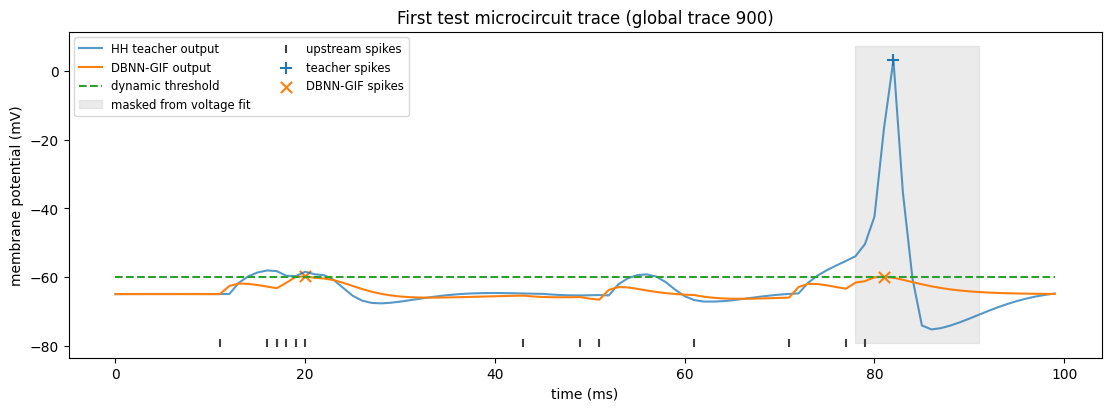

In [8]:
test_trace_index = 0
teacher_voltage_mv = test_data['targets'][test_trace_index]
teacher_spike_times_ms = test_data['spike_times_ms'][test_trace_index]
fit_mask = test_data['mask'][test_trace_index]
input_event_times_ms = runtime_plan.events.time_ms
runtime_spike_times_ms = np.asarray(runtime_spikes.time.to_decimal(u.ms))

figure, axis = plt.subplots(figsize=(11, 4), constrained_layout=True)
axis.plot(time_ms, teacher_voltage_mv, color='tab:blue', alpha=0.75, label='HH teacher output')
axis.plot(time_ms, runtime_voltage_mv, color='tab:orange', label='DBNN-GIF output')
axis.plot(time_ms, runtime_threshold_mv, color='tab:green', linestyle='--', label='dynamic threshold')
lower, upper = axis.get_ylim()
axis.fill_between(time_ms, lower, upper, where=~fit_mask, step='post', color='0.7', alpha=0.25, label='masked from voltage fit')
axis.scatter(input_event_times_ms, np.full(input_event_times_ms.shape, lower), marker='|', s=28, color='0.25', label='upstream spikes')
axis.scatter(teacher_spike_times_ms, np.interp(teacher_spike_times_ms, time_ms, teacher_voltage_mv), marker='+', s=75, color='tab:blue', label='teacher spikes')
axis.scatter(runtime_spike_times_ms, np.interp(runtime_spike_times_ms, time_ms, runtime_voltage_mv), marker='x', s=65, color='tab:orange', label='DBNN-GIF spikes')
axis.set(xlabel='time (ms)', ylabel='membrane potential (mV)', title=f'First test microcircuit trace (global trace {selected_trace})')
axis.legend(ncol=2, fontsize='small')
plt.show()